Columns in transcript: ['age_bucket', 'audio_duration_sec', 'audio_path', 'child_id', 'filesize_bytes', 'md5_hash', 'phonetic_text', 'session_id', 'utterance_id']

=== Audio Folder Stats (audio/) ===
num_audio_files_in_folder: 12043
num_transcript_rows_for_audio_folder: 12043
num_unique_children: 107
total_duration_hours: 6.4412
mean_duration_sec: 1.9254
median_duration_sec: 1.4170
p95_duration_sec: 5.0336
max_duration_sec: 21.3820


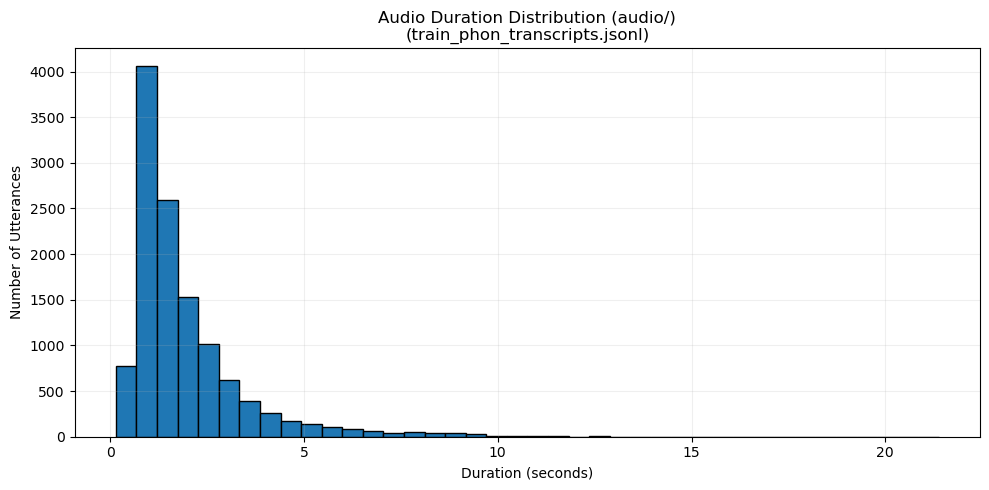

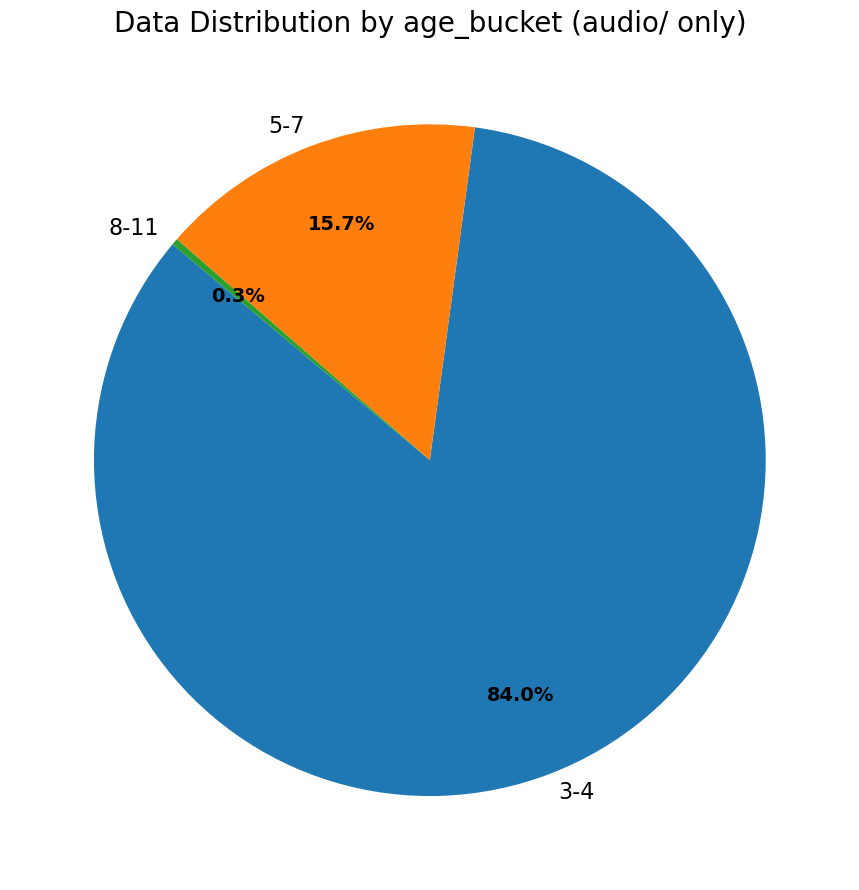


Saved figures:
- /home/armaan/Trash_Code/mlpr/project/audio_duration_distribution.png
- /home/armaan/Trash_Code/mlpr/project/audio_distribution_pie.png


In [4]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths
project_root = Path.cwd()
audio_dir = project_root / "audio"
transcript_path = project_root / "train_phon_transcripts.jsonl"

# Load transcript metadata
records = []
with transcript_path.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

meta = pd.DataFrame(records)
print("Columns in transcript:", sorted(meta.columns.tolist()))

# Keep only entries whose audio_path points to the target folder (audio, not audio2)
meta_audio = meta[meta["audio_path"].astype(str).str.startswith("audio/")].copy()

# Add derived fields
meta_audio["duration_sec"] = pd.to_numeric(meta_audio["audio_duration_sec"], errors="coerce")
meta_audio["duration_min"] = meta_audio["duration_sec"] / 60.0

# Prefer phonetic_text for token length; fallback to other likely text columns
token_col_candidates = [
    "phonetic_text",
    "phones",
    "phoneme",
    "phonemes",
    "transcript",
    "text",
    "normalized_text",
]
token_col = next((c for c in token_col_candidates if c in meta_audio.columns), None)
if token_col is not None:
    meta_audio["utterance_len_tokens"] = (
        meta_audio[token_col].fillna("").astype(str).str.split().str.len()
    )
else:
    meta_audio["utterance_len_tokens"] = np.nan

# Compute summary stats
all_audio_files = list(audio_dir.glob("*.flac"))
stats = {
    "num_audio_files_in_folder": len(all_audio_files),
    "num_transcript_rows_for_audio_folder": int(meta_audio.shape[0]),
    "num_unique_children": int(meta_audio["child_id"].nunique()) if "child_id" in meta_audio.columns else -1,
    "total_duration_hours": float(meta_audio["duration_sec"].sum() / 3600.0),
    "mean_duration_sec": float(meta_audio["duration_sec"].mean()),
    "median_duration_sec": float(meta_audio["duration_sec"].median()),
    "p95_duration_sec": float(meta_audio["duration_sec"].quantile(0.95)),
    "max_duration_sec": float(meta_audio["duration_sec"].max()),
}

print("\n=== Audio Folder Stats (audio/) ===")
for k, v in stats.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

# Chart 1: duration distribution histogram
plt.figure(figsize=(10, 5))
plt.hist(meta_audio["duration_sec"].dropna(), bins=40, edgecolor="black")
plt.title("Audio Duration Distribution (audio/)\n(train_phon_transcripts.jsonl)")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Utterances")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(project_root / "audio_duration_distribution.png", dpi=160)
plt.show()

# Relevant pie metric: age bucket distribution (fallback to child_id groups if missing)
pie_col = "age_bucket" if "age_bucket" in meta_audio.columns else None
if pie_col is not None:
    pie_counts = (
        meta_audio[pie_col]
        .fillna("unknown")
        .astype(str)
        .replace("", "unknown")
        .value_counts()
    )

    plt.figure(figsize=(9, 9))
    wedges, texts, autotexts = plt.pie(
        pie_counts.values,
        labels=pie_counts.index,
        autopct="%1.1f%%",
        startangle=140,
        pctdistance=0.75,
        labeldistance=1.06,
        textprops={"fontsize": 16},
    )
    for t in autotexts:
        t.set_fontsize(14)
        t.set_weight("bold")

    plt.title(f"Data Distribution by {pie_col} (audio/ only)", fontsize=20)
    plt.tight_layout()
    plt.savefig(project_root / "audio_distribution_pie.png", dpi=160)
    plt.show()
else:
    print("No age_bucket column found for pie chart.")

print("\nSaved figures:")
print("-", project_root / "audio_duration_distribution.png")
if pie_col is not None:
    print("-", project_root / "audio_distribution_pie.png")

In [5]:
# Distinct phoneme-class counts from phonetic_text (audio/ subset)
phon_text = meta_audio["phonetic_text"].dropna().astype(str)

# Interpretation 1: whitespace-separated units
distinct_token_classes = set()
for s in phon_text:
    distinct_token_classes.update(tok for tok in s.split() if tok)

# Interpretation 2: character-level IPA symbols (excluding spaces)
distinct_symbols = {ch for s in phon_text for ch in s if not ch.isspace()}

print(f"Distinct phoneme classes (whitespace tokens): {len(distinct_token_classes)}")
print(f"Distinct IPA symbols (character-level): {len(distinct_symbols)}")

# Optional quick preview
print("Sample token classes:", sorted(distinct_token_classes)[:25])

Distinct phoneme classes (whitespace tokens): 8720
Distinct IPA symbols (character-level): 49
Sample token classes: ['b', 'be', 'bebi', 'bed', 'beehɪ', 'begɑʊʝboʊɫðən', 'bei', 'beibi', 'beibis', 'beibiz', 'beibið', 'beibiɛː', 'beif', 'beigol', 'beik', 'beip', 'beiv', 'beiz', 'beið', 'beiŋ', 'beiʔθ', 'beiːv', 'beiθ', 'bejoi', 'ben']
